# ANNEXURE: Data Analysis


# A1. Setup and Data Loading

## A1.1 Library Imports

In [50]:
import pandas as pd
import numpy as np
import json
import os
import warnings

warnings.filterwarnings('ignore')

print("Core libraries ready.")

Core libraries ready.


## A1.2 Data Loading

In [51]:
# Load the CSV files - these are straightforward
products_csv = pd.read_csv("JCPenneyFiles/products.csv")
reviews_csv = pd.read_csv("JCPenneyFiles/reviews.csv")
users_csv = pd.read_csv("JCPenneyFiles/users.csv")

# Load NDJSON files in one step each
products_json = pd.read_json("JCPenneyFiles/jcpenney_products.json", lines=True)
reviewers_json = pd.read_json("JCPenneyFiles/jcpenney_reviewers.json", lines=True)
 

# Check what we loaded
print(f"products_csv   : {len(products_csv)} rows")
print(f"reviews_csv    : {len(reviews_csv)} rows")
print(f"users_csv      : {len(users_csv)} rows")
print(f"products_json  : {len(products_json)} rows")
print(f"reviewers_json : {len(reviewers_json)} rows")

products_csv   : 7982 rows
reviews_csv    : 39063 rows
users_csv      : 5000 rows
products_json  : 7982 rows
reviewers_json : 5000 rows


In [52]:
# We want a quick snapshot of each dataset's column types and a sample row
# so we can spot type issues before cleaning.

print("--- products_json ---")
print(products_json.dtypes)
print(products_json[["uniq_id", "list_price", "sale_price", "average_product_rating", "brand", "category_tree"]].head(2))

print("\n--- reviews_csv ---")
print(reviews_csv.dtypes)
print(reviews_csv.head(2))

print("\n--- users_csv ---")
print(users_csv.dtypes)
print(users_csv.head(2))

--- products_json ---
uniq_id                    object
sku                        object
name_title                 object
description                object
list_price                 object
sale_price                 object
category                   object
category_tree              object
average_product_rating    float64
product_url                object
product_image_urls         object
brand                      object
total_number_reviews        int64
Reviews                    object
Bought With                object
dtype: object
                            uniq_id list_price sale_price  \
0  b6c0b6bea69c722939585baeac73c13d      41.09      24.16   
1  93e5272c51d8cce02597e3ce67b7ad0a      41.09      24.16   

   average_product_rating          brand                 category_tree  
0                   2.625  Alfred Dunner  jcpenney|women|alfred dunner  
1                   3.000  Alfred Dunner  jcpenney|women|alfred dunner  

--- reviews_csv ---
Uniq_id     object
Username   

# A2. Data Quality and Preparation

## A2.1 Data Quality Audit

In [53]:
# Before cleaning anything, we need to understand what problems exist in each dataset.
# We check for missing values and duplicate rows so we know exactly what needs fixing.

print("Missing Values")
print("  products_json :", products_json.isnull().sum().sum())
print("  reviews_csv   :", reviews_csv.isnull().sum().sum())
print("  users_csv     :", users_csv.isnull().sum().sum())

print("\nDuplicate Rows")
print("  products_json :", products_json.duplicated(subset=["uniq_id"]).sum())
print("  reviews_csv   :", reviews_csv.duplicated().sum())
print("  users_csv     :", users_csv.duplicated().sum())

Missing Values
  products_json : 0
  reviews_csv   : 0
  users_csv     : 0

Duplicate Rows
  products_json : 0
  reviews_csv   : 0
  users_csv     : 0


## A2.2 Data Cleaning and Transformation

In [54]:
# Clean up the products data
products = products_json.copy()

# Convert price columns from text to numbers
products["list_price"] = pd.to_numeric(products["list_price"], errors="coerce")
products["sale_price"] = pd.to_numeric(products["sale_price"], errors="coerce")

# Calculate discount percentage
products["discount_pct"] = (products["list_price"] - products["sale_price"]) / products["list_price"] * 100
products["discount_pct"] = products["discount_pct"].round(1)

# Extract main category and subcategory from category_tree
# The category_tree format is: "jcpenney|main_category|subcategory|..."
# Example: "jcpenney|women|alfred dunner" → main: women, sub: alfred dunner

# Step 1: Define navigation/promotional terms to exclude
nav_tokens = ['jcpenney', 'view all', 'sale', 'clearance', 'view all brands', 
              'shops', 'deals', 'search-results', "outfits you'll love", 
              'specialty-sizing', 'hidden-categories']

# Step 2: Extract and clean categories
def extract_categories(category_tree):
    # Handle missing values
    if not isinstance(category_tree, str):
        return pd.Series({'main_category': None, 'sub_category': None})
    
    # Split by pipe and clean whitespace
    parts = [p.strip().lower() for p in category_tree.split('|') if p.strip()]
    
    # Remove navigation tokens
    parts = [p for p in parts if p not in nav_tokens]
    
    # Extract main and subcategory
    main = parts[0] if len(parts) > 0 else None
    sub = parts[1] if len(parts) > 1 else None
    
    return pd.Series({'main_category': main, 'sub_category': sub})

# Step 3: Apply extraction to all products
products[['main_category', 'sub_category']] = products['category_tree'].apply(extract_categories)

# Step 4: Keep the old 'category' column for backward compatibility (uses main_category)
products['category'] = products['main_category'].str.title()

# Clean up the users data
users = users_csv.copy()

# Remove duplicate usernames (keep first occurrence)
users = users.drop_duplicates(subset=["Username"], keep="first")

# Convert DOB to datetime
users["DOB"] = pd.to_datetime(users["DOB"], format="%d.%m.%Y", errors="coerce")

# Calculate age from DOB
today = pd.Timestamp("today")
users["age"] = (today - users["DOB"]).dt.days / 365.25
users["age"] = users["age"].round(0)

# IMPORTANT: Extract reviews from JSON instead of CSV
# Analysis revealed that reviews.csv has corrupted scores that don't match review text
# The JSON source contains accurate ratings that align with customer sentiment

# Extract reviews from products_json
reviews_list = []
for idx, product in products_json.iterrows():
    product_id = product["uniq_id"]
    if "Reviews" in product and product["Reviews"]:
        for review in product["Reviews"]:
            reviews_list.append({
                "product_id": product_id,
                "username": review["User"],
                "score": review["Score"],
                "review_text": review["Review"]
            })

reviews = pd.DataFrame(reviews_list)

print("Data Cleaning Complete")
print(f"  Products : {len(products):,}")
print(f"  Users    : {len(users):,} (unique users)")
print(f"  Reviews  : {len(reviews):,} (from JSON source)")
print(f"\nProducts with prices : {products['list_price'].notna().sum():,} / {len(products):,}")
print(f"Unique main categories : {products['main_category'].nunique()}")
print(f"Unique subcategories   : {products['sub_category'].nunique()}")
print(f"\nData Quality Notes:")
print(f"  - Using reviews from JSON (not CSV) due to score accuracy issues")
print(f"  - Removed duplicate usernames from users dataset")
print(f"  - Improved category extraction to separate main/sub categories")
print(f"  - Excluded navigation terms (view all, sale, etc.) from categories")

Data Cleaning Complete
  Products : 7,982
  Users    : 4,999 (unique users)
  Reviews  : 39,063 (from JSON source)

Products with prices : 5,816 / 7,982
Unique main categories : 975
Unique subcategories   : 688

Data Quality Notes:
  - Using reviews from JSON (not CSV) due to score accuracy issues
  - Removed duplicate usernames from users dataset
  - Improved category extraction to separate main/sub categories
  - Excluded navigation terms (view all, sale, etc.) from categories


## A2.3 Dataset Merging

In [55]:
# Merge all the data together to create one master dataset
# Start with reviews as the base

# First, merge reviews with product information
df = reviews.merge(
    products[["uniq_id", "name_title", "brand", "category", "list_price", "sale_price", "discount_pct"]],
    left_on="product_id",
    right_on="uniq_id",
    how="left"
)

# Remove the duplicate uniq_id column
df = df.drop(columns=["uniq_id"])

# Now add user information
df = df.merge(
    users[["Username", "State", "age"]],
    left_on="username",
    right_on="Username",
    how="left"
)

# Remove the duplicate Username column
df = df.drop(columns=["Username"])

print("Master Dataset Created")
print(f"  Total reviews : {len(df):,}")
print(f"  Columns       : {len(df.columns)}")

Master Dataset Created
  Total reviews : 39,063
  Columns       : 12


# A3. Exploratory Data Analysis

## A3.1 Visualization Setup

In [56]:
# We need visualization libraries for charts — importing them here, not at the top,
# because they are only needed from this section onwards.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Visualization libraries ready")

Visualization libraries ready


In [57]:
## A3.2 Product Category Distribution

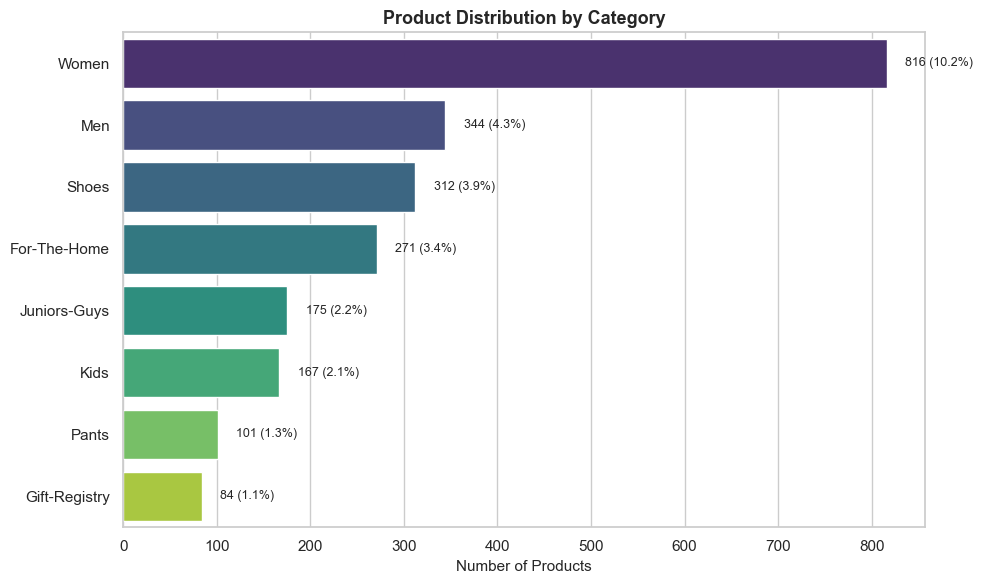

Category Distribution
  Women                : 816 (10.2%)
  Men                  : 344 (4.3%)
  Shoes                : 312 (3.9%)
  For-The-Home         : 271 (3.4%)
  Juniors-Guys         : 175 (2.2%)
  Kids                 : 167 (2.1%)
  Pants                : 101 (1.3%)
  Gift-Registry        : 84 (1.1%)
  Other                : 4,183 (52.4%)


In [58]:
# Show the main product categories and their distribution
# Get top 8 categories, group the rest as "Other"

top_8 = products["category"].value_counts().head(8)
other_count = products["category"].value_counts()[8:].sum()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_8.values, y=top_8.index, palette="viridis", ax=ax)
ax.set_xlabel("Number of Products", fontsize=11)
ax.set_ylabel("")
ax.set_title("Product Distribution by Category", fontsize=13, fontweight="bold")

# Add count labels
for i, (cat, count) in enumerate(top_8.items()):
    pct = count / len(products) * 100
    ax.text(count + 20, i, f"{count:,} ({pct:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("Category Distribution")
for cat, count in top_8.items():
    pct = count / len(products) * 100
    print(f"  {cat:20s} : {count:,} ({pct:.1f}%)")
print(f"  {'Other':20s} : {other_count:,} ({other_count/len(products)*100:.1f}%)")

Price range: $8.01 - $17122.17
95th percentile: $471.15
Products above 95th percentile: 289


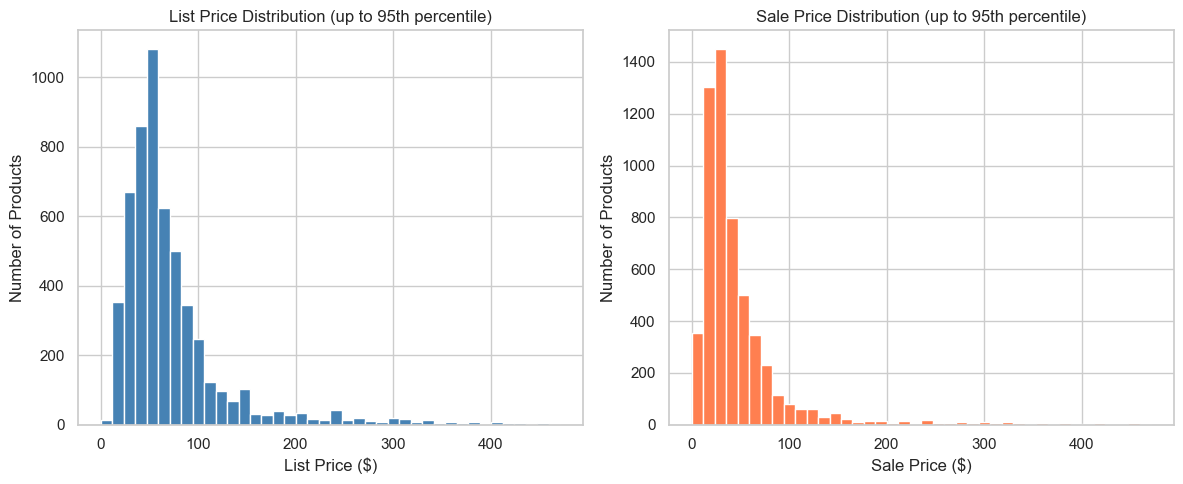


Price Summary
  Median list price  : $58.01
  Median sale price  : $32.63
  Average discount   : 41.5%


In [59]:
# Analyze pricing structure and check for outliers.
# Show distribution up to 95th percentile for clarity.

# Filter out products with negative prices (data quality issue)
products_with_price = products[(products["list_price"].notna()) & (products["list_price"] > 0)]

price_95th = products_with_price["list_price"].quantile(0.95)
print(f"Price range: ${products_with_price['list_price'].min():.2f} - ${products_with_price['list_price'].max():.2f}")
print(f"95th percentile: ${price_95th:.2f}")
print(f"Products above 95th percentile: {(products_with_price['list_price'] > price_95th).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(products_with_price["list_price"], bins=40, color="steelblue", edgecolor="white", range=(0, price_95th))
axes[0].set_xlabel("List Price ($)")
axes[0].set_ylabel("Number of Products")
axes[0].set_title("List Price Distribution (up to 95th percentile)")

axes[1].hist(products_with_price["sale_price"], bins=40, color="coral", edgecolor="white", range=(0, price_95th))
axes[1].set_xlabel("Sale Price ($)")
axes[1].set_ylabel("Number of Products")
axes[1].set_title("Sale Price Distribution (up to 95th percentile)")

plt.tight_layout()
plt.show()

print("\nPrice Summary")
print(f"  Median list price  : ${products_with_price['list_price'].median():.2f}")
print(f"  Median sale price  : ${products_with_price['sale_price'].median():.2f}")
print(f"  Average discount   : {products_with_price['discount_pct'].mean():.1f}%")

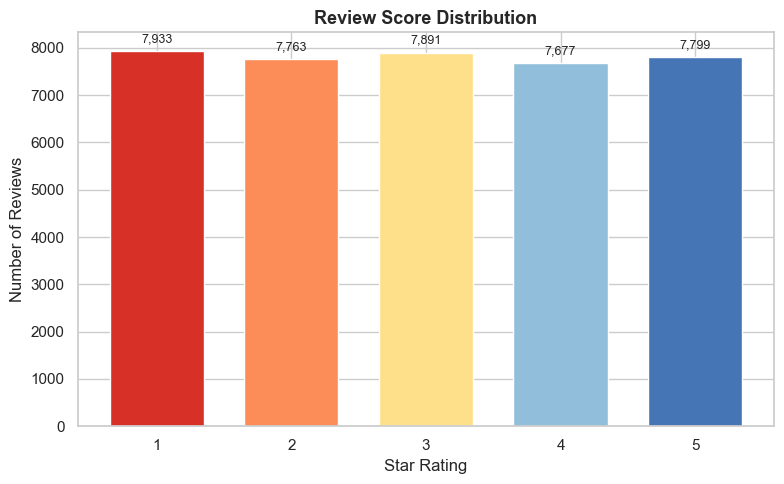

Review Score Summary
  Total reviews        : 39,063
  Positive (4-5 stars) : 39.6%
  Average score        : 2.99


In [60]:
# Show how customers rate products - positive or negative?
# Note: Using reviews from JSON source (accurate scores)

score_counts = reviews["score"].value_counts().sort_index()

# Create bar chart with different colors for each rating
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#d73027", "#fc8d59", "#fee08b", "#91bfdb", "#4575b4"]
bars = ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor="white", width=0.7)

ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Reviews")
ax.set_title("Review Score Distribution", fontsize=13, fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])

# Add count labels on top of bars
for i, score in enumerate(score_counts.index):
    count = score_counts.values[i]
    ax.text(score, count + 200, f"{count:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Calculate positive review percentage
positive_pct = (reviews["score"] >= 4).sum() / len(reviews) * 100

print("Review Score Summary")
print(f"  Total reviews        : {len(reviews):,}")
print(f"  Positive (4-5 stars) : {positive_pct:.1f}%")
print(f"  Average score        : {reviews['score'].mean():.2f}")

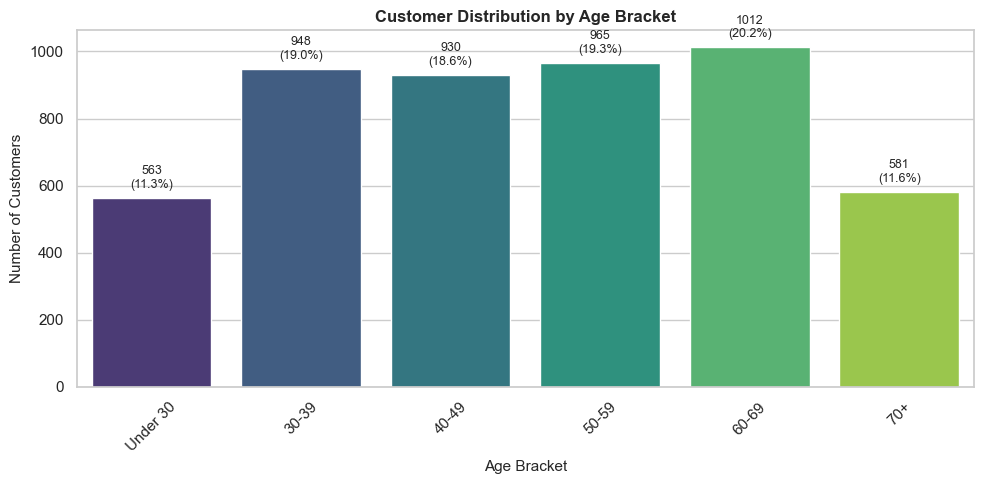

Customer Age Distribution
  Total customers : 4,999
  Median age      : 51 years
  Age range       : 25 - 76 years

Age Bracket Breakdown:
  Under 30   : 563 (11.3%)
  30-39      : 948 (19.0%)
  40-49      : 930 (18.6%)
  50-59      : 965 (19.3%)
  60-69      : 1,012 (20.2%)
  70+        : 581 (11.6%)


In [61]:
# Show customer age distribution using age brackets

users_with_age = users[users["age"].notna()]

# Create age brackets
age_brackets = pd.cut(
    users_with_age["age"],
    bins=[0, 30, 40, 50, 60, 70, 100],
    labels=["Under 30", "30-39", "40-49", "50-59", "60-69", "70+"]
)

age_counts = age_brackets.value_counts().sort_index()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis", ax=ax)
ax.set_xlabel("Age Bracket", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.set_title("Customer Distribution by Age Bracket", fontsize=12, fontweight="bold")
ax.tick_params(axis='x', rotation=45)

# Add labels on bars
for i in range(len(age_counts)):
    count = age_counts.values[i]
    pct = count / len(users_with_age) * 100
    ax.text(i, count + 30, f"{count}\n({pct:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("Customer Age Distribution")
print(f"  Total customers : {len(users_with_age):,}")
print(f"  Median age      : {users_with_age['age'].median():.0f} years")
print(f"  Age range       : {users_with_age['age'].min():.0f} - {users_with_age['age'].max():.0f} years")
print(f"\nAge Bracket Breakdown:")
for bracket, count in age_counts.items():
    pct = count / len(users_with_age) * 100
    print(f"  {bracket:10s} : {count:,} ({pct:.1f}%)")

In [62]:
# Show geographic distribution on a US map

import plotly.graph_objects as go

# Count customers by state
state_counts = users["State"].value_counts().reset_index()
state_counts.columns = ["State", "Customers"]

# We need state abbreviations for the map to work
# Creating a simple mapping of state names to codes
state_codes = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Add state codes to our data
state_counts["Code"] = state_counts["State"].map(state_codes)

# Create the map
fig = go.Figure(data=go.Choropleth(
    locations=state_counts["Code"],
    z=state_counts["Customers"],
    locationmode='USA-states',
    colorscale='Reds',
    colorbar_title="Customers",
    text=state_counts["State"],
    hovertemplate='<b>%{text}</b><br>Customers: %{z}<extra></extra>'
))

fig.update_layout(
    title_text='Customer Distribution Across US States',
    geo_scope='usa',
    width=1000,
    height=600
)

fig.show()

# Print summary
total_states = users['State'].nunique()
print("Geographic Distribution Summary")
print(f"  Total customers    : {len(users):,}")
print(f"  States represented : {total_states}")
print(f"  Average per state  : {len(users) / total_states:.1f}")
print(f"\nTop 5 states:")
for i in range(5):
    state = state_counts.iloc[i]["State"]
    count = state_counts.iloc[i]["Customers"]
    pct = count / len(users) * 100
    print(f"  {state:25s} : {count:,} ({pct:.1f}%)")
print(f"\nNote: Distribution is very even across states")

Geographic Distribution Summary
  Total customers    : 4,999
  States represented : 57
  Average per state  : 87.7

Top 5 states:
  Massachusetts             : 107 (2.1%)
  Delaware                  : 106 (2.1%)
  Vermont                   : 103 (2.1%)
  Northern Mariana Islands  : 102 (2.0%)
  New Jersey                : 101 (2.0%)

Note: Distribution is very even across states


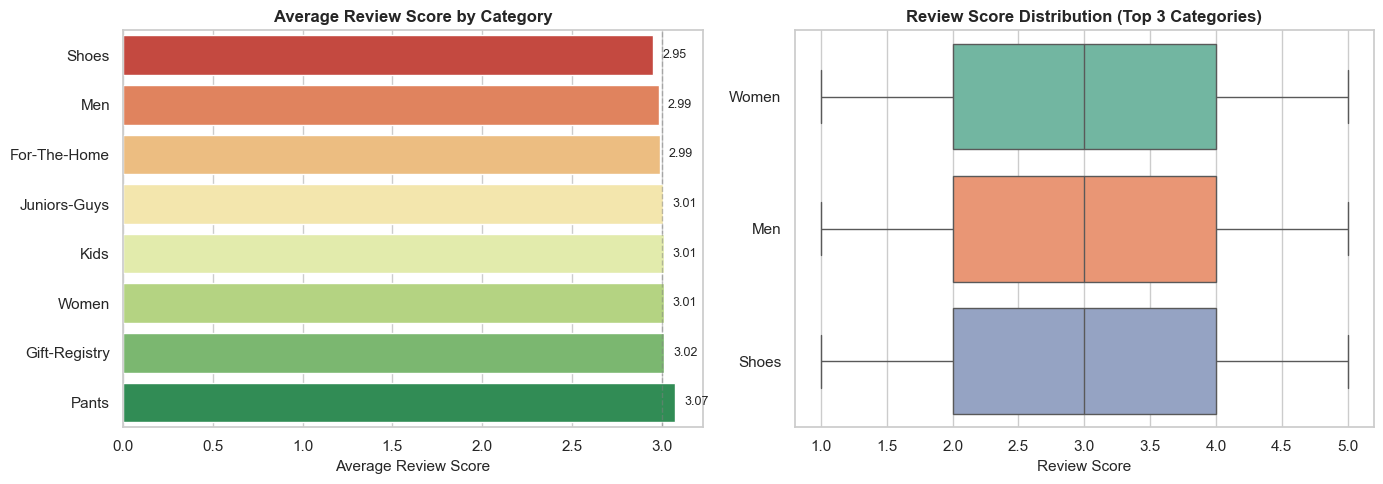

Review Score Analysis by Category
  Overall average score : 2.99

Average scores by category:
  Shoes                : 2.95 (1,640 reviews)
  Men                  : 2.99 (1,508 reviews)
  For-The-Home         : 2.99 (1,381 reviews)
  Juniors-Guys         : 3.01 (699 reviews)
  Kids                 : 3.01 (611 reviews)
  Women                : 3.01 (4,180 reviews)
  Gift-Registry        : 3.02 (383 reviews)
  Pants                : 3.07 (702 reviews)


In [63]:
# Analyze review scores by product category to identify problem areas
# Note: Using reviews from JSON source (accurate scores)

# Get top 8 categories by product count
top_categories = products["category"].value_counts().head(8).index

# Filter master dataset to only top categories
df_top = df[df["category"].isin(top_categories)].copy()

# Calculate average score by category
avg_scores = df_top.groupby("category")["score"].mean().sort_values()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average review score by category
sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="RdYlGn", ax=axes[0])
axes[0].set_xlabel("Average Review Score", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_title("Average Review Score by Category", fontsize=12, fontweight="bold")
axes[0].axvline(x=3.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for i, (cat, score) in enumerate(avg_scores.items()):
    axes[0].text(score + 0.05, i, f"{score:.2f}", va="center", fontsize=9)

# Chart 2: Review score distribution for top 3 categories
top_3_cats = products["category"].value_counts().head(3).index
df_top3 = df[df["category"].isin(top_3_cats)]

sns.boxplot(data=df_top3, y="category", x="score", palette="Set2", ax=axes[1])
axes[1].set_xlabel("Review Score", fontsize=11)
axes[1].set_ylabel("")
axes[1].set_title("Review Score Distribution (Top 3 Categories)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("Review Score Analysis by Category")
print(f"  Overall average score : {df['score'].mean():.2f}")
print(f"\nAverage scores by category:")
for cat, score in avg_scores.items():
    count = df_top[df_top["category"] == cat].shape[0]
    print(f"  {cat:20s} : {score:.2f} ({count:,} reviews)")

## A3.8 Brand Performance Analysis

## A3.9 Discount Effectiveness Analysis

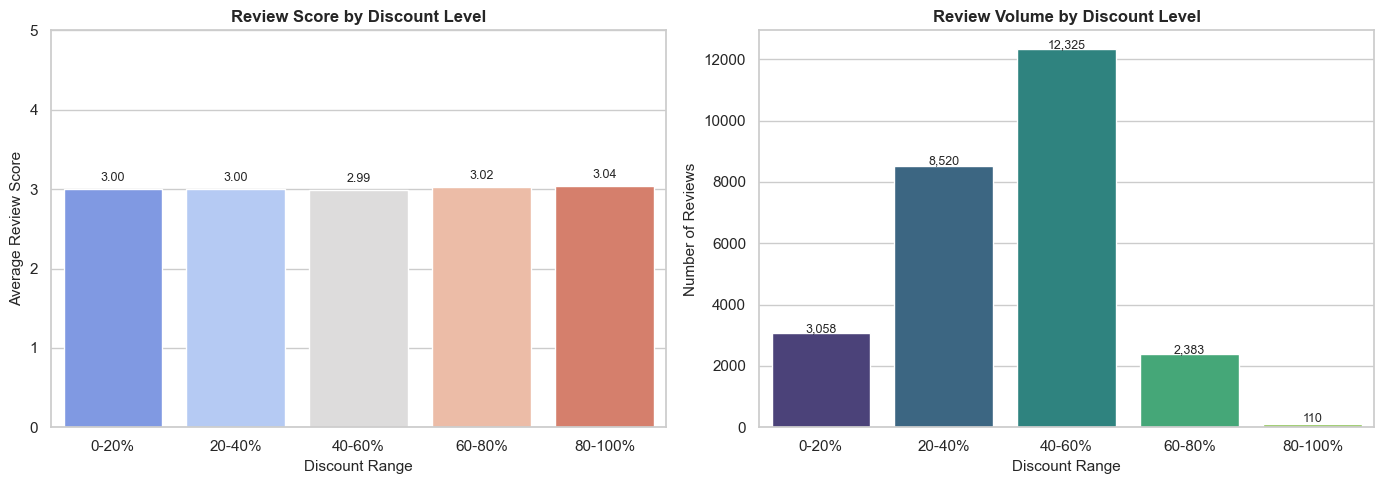

Discount Effectiveness Analysis
  Reviews with discount data : 26,848

Average score by discount range:
  0-20%      : 3.00 (3,058 reviews)
  20-40%     : 3.00 (8,520 reviews)
  40-60%     : 2.99 (12,325 reviews)
  60-80%     : 3.02 (2,383 reviews)
  80-100%    : 3.04 (110 reviews)


In [64]:
# Does discount percentage affect review scores?
# Let's see if bigger discounts lead to better reviews
# Note: Using reviews from JSON source (accurate scores)

# Filter to reviews that have discount data
df_discount = df[df["discount_pct"].notna()].copy()

# Create discount ranges
df_discount["discount_range"] = pd.cut(
    df_discount["discount_pct"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
)

# Calculate average score for each discount range
discount_summary = df_discount.groupby("discount_range")["score"].agg(["mean", "count"]).reset_index()
discount_summary.columns = ["discount_range", "avg_score", "review_count"]

# Create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average score by discount range
sns.barplot(data=discount_summary, x="discount_range", y="avg_score", palette="coolwarm", ax=axes[0])
axes[0].set_xlabel("Discount Range", fontsize=11)
axes[0].set_ylabel("Average Review Score", fontsize=11)
axes[0].set_title("Review Score by Discount Level", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 5)

# Add score labels
for i in range(len(discount_summary)):
    score = discount_summary.iloc[i]["avg_score"]
    axes[0].text(i, score + 0.1, f"{score:.2f}", ha="center", fontsize=9)

# Chart 2: Review count by discount range
sns.barplot(data=discount_summary, x="discount_range", y="review_count", palette="viridis", ax=axes[1])
axes[1].set_xlabel("Discount Range", fontsize=11)
axes[1].set_ylabel("Number of Reviews", fontsize=11)
axes[1].set_title("Review Volume by Discount Level", fontsize=12, fontweight="bold")

# Add count labels
for i in range(len(discount_summary)):
    count = discount_summary.iloc[i]["review_count"]
    axes[1].text(i, count + 50, f"{int(count):,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("Discount Effectiveness Analysis")
print(f"  Reviews with discount data : {len(df_discount):,}")
print(f"\nAverage score by discount range:")
for i in range(len(discount_summary)):
    range_label = discount_summary.iloc[i]["discount_range"]
    score = discount_summary.iloc[i]["avg_score"]
    count = discount_summary.iloc[i]["review_count"]
    print(f"  {range_label:10s} : {score:.2f} ({int(count):,} reviews)")

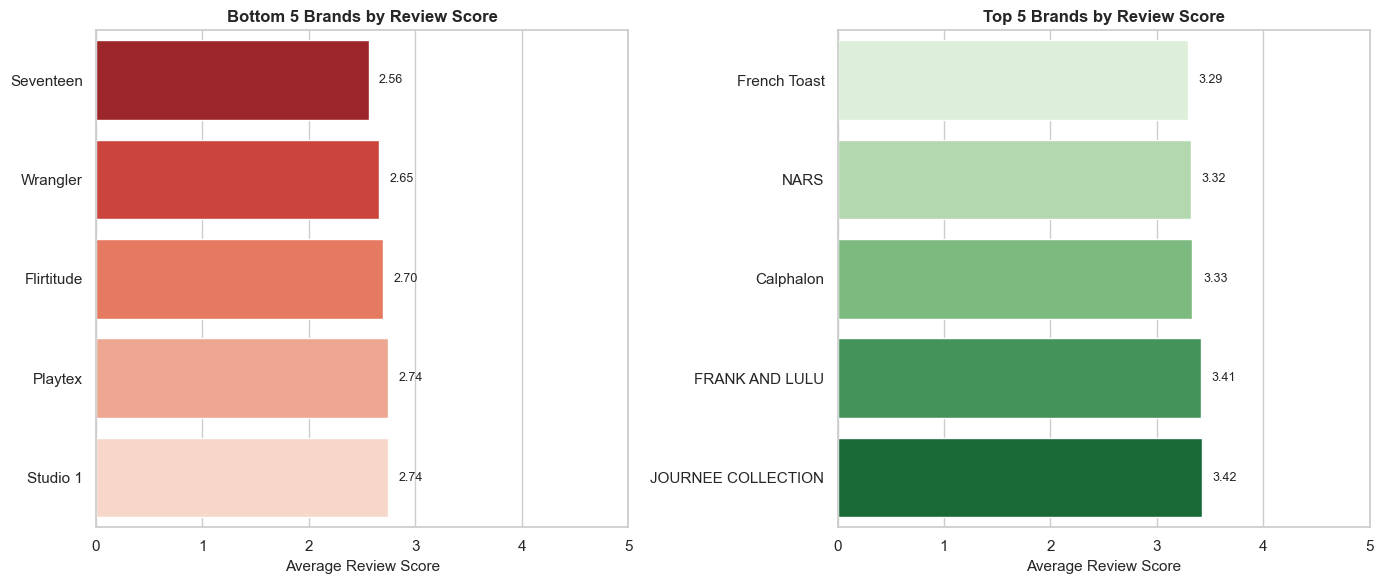

Brand Performance Summary
  Brands analyzed (50+ reviews) : 126

Bottom 5 brands:
  Seventeen                      : 2.56 (50 reviews)
  Wrangler                       : 2.65 (55 reviews)
  Flirtitude                     : 2.70 (133 reviews)
  Playtex                        : 2.74 (105 reviews)
  Studio 1                       : 2.74 (70 reviews)

Top 5 brands:
  French Toast                   : 3.29 (93 reviews)
  NARS                           : 3.32 (69 reviews)
  Calphalon                      : 3.33 (57 reviews)
  FRANK AND LULU                 : 3.41 (56 reviews)
  JOURNEE COLLECTION             : 3.42 (52 reviews)


In [65]:
# Compare brand performance - which brands get better reviews?
# Only look at brands with at least 50 reviews to be fair
# Note: Using reviews from JSON source (accurate scores)

# Group by brand and calculate statistics
brand_stats = df.groupby("brand").agg({
    "score": ["mean", "count"]
})

# Flatten the column names
brand_stats.columns = ["avg_score", "review_count"]
brand_stats = brand_stats.reset_index()

# Filter to brands with at least 50 reviews
brand_stats = brand_stats[brand_stats["review_count"] >= 50]

# Sort by average score
brand_stats = brand_stats.sort_values("avg_score")

# Get bottom 5 and top 5 brands
bottom_5 = brand_stats.head(5)
top_5 = brand_stats.tail(5)

# Create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Bottom 5 brands
sns.barplot(data=bottom_5, y="brand", x="avg_score", palette="Reds_r", ax=axes[0])
axes[0].set_xlabel("Average Review Score", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_title("Bottom 5 Brands by Review Score", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 5)

# Add score labels
for i in range(len(bottom_5)):
    score = bottom_5.iloc[i]["avg_score"]
    axes[0].text(score + 0.1, i, f"{score:.2f}", va="center", fontsize=9)

# Chart 2: Top 5 brands
sns.barplot(data=top_5, y="brand", x="avg_score", palette="Greens", ax=axes[1])
axes[1].set_xlabel("Average Review Score", fontsize=11)
axes[1].set_ylabel("")
axes[1].set_title("Top 5 Brands by Review Score", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 5)

# Add score labels
for i in range(len(top_5)):
    score = top_5.iloc[i]["avg_score"]
    axes[1].text(score + 0.1, i, f"{score:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("Brand Performance Summary")
print(f"  Brands analyzed (50+ reviews) : {len(brand_stats)}")
print(f"\nBottom 5 brands:")
for i in range(len(bottom_5)):
    brand = bottom_5.iloc[i]["brand"]
    score = bottom_5.iloc[i]["avg_score"]
    count = bottom_5.iloc[i]["review_count"]
    print(f"  {brand:30s} : {score:.2f} ({int(count)} reviews)")
print(f"\nTop 5 brands:")
for i in range(len(top_5)):
    brand = top_5.iloc[i]["brand"]
    score = top_5.iloc[i]["avg_score"]
    count = top_5.iloc[i]["review_count"]
    print(f"  {brand:30s} : {score:.2f} ({int(count)} reviews)")